In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sbrn

# Cleaning of Data

In [8]:
trip_data = pd.read_csv(r"C:\Users\naila\Downloads\travel+reviews.zip")
trip_data_without_userid = trip_data.drop(columns="User ID")
trip_data_without_userid = trip_data_without_userid.rename(columns={
    "Category 1": "Art Galleries",
    "Category 2": "Dance Clubs",
    "Category 3": "Juice Bars",
    "Category 4": "Restaurants",
    "Category 5": "Museums",
    "Category 6": "Resorts",
    "Category 7": "Parks/Picnic Spots",
    "Category 8": "Beaches",
    "Category 9": "Theaters",
    "Category 10": "Religious Insitutions",
})
print(f"Missing Values in Dataset: {trip_data_without_userid.isna().sum()}")
print(f"Duplicates in Dataset: {trip_data_without_userid.duplicated().sum()}")


Missing Values in Dataset: Art Galleries            0
Dance Clubs              0
Juice Bars               0
Restaurants              0
Museums                  0
Resorts                  0
Parks/Picnic Spots       0
Beaches                  0
Theaters                 0
Religious Insitutions    0
dtype: int64
Duplicates in Dataset: 39


# Exploratory Data Analysis

In [9]:
#droping duplicates
trip_data_without_userid = trip_data_without_userid.drop_duplicates()
print(f"Duplicates in Dataset: {trip_data_without_userid.duplicated().sum()}")

Duplicates in Dataset: 0


<Axes: >

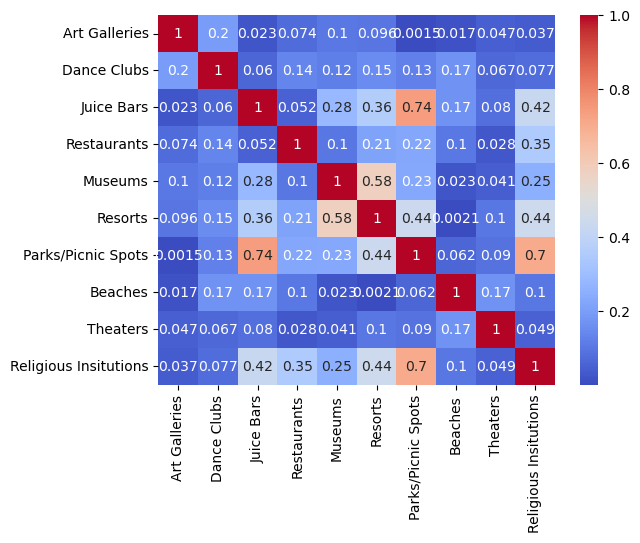

In [10]:
# initial correlation tests
correlation_matrix_for_initial_data = trip_data_without_userid.corr().abs()
correlation_matrix_for_initial_data
sbrn.heatmap(correlation_matrix_for_initial_data, annot=True, cmap='coolwarm')
#sbrn.heatmap(correlation_matrix_for_initial_data)

In [11]:
# cleaning and preprocessing the data
mean_of_numerics = trip_data_without_userid.mean(numeric_only=True)
print(mean_of_numerics)

trip_data_without_userid.describe()

Art Galleries            0.897917
Dance Clubs              1.354899
Juice Bars               0.990903
Restaurants              0.533007
Museums                  0.936706
Resorts                  1.841031
Parks/Picnic Spots       3.180744
Beaches                  2.836854
Theaters                 1.570925
Religious Insitutions    2.804017
dtype: float64


,Art Galleries,Dance Clubs,Juice Bars,Restaurants,Museums,Resorts,Parks/Picnic Spots,Beaches,Theaters,Religious Insitutions
count,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000
mean,0.897917,1.354899,0.990903,0.533007,0.936706,1.841031,3.180744,2.836854,1.570925,2.804017
std,0.328516,0.481099,0.770791,0.284113,0.441120,0.541736,0.007696,0.137620,0.366983,0.319279
min,0.340000,0.000000,0.130000,0.150000,0.060000,0.140000,3.160000,2.420000,0.740000,2.140000
25%,0.700000,1.080000,0.270000,0.410000,0.620000,1.460000,3.180000,2.740000,1.310000,2.540000
50%,0.830000,1.280000,0.800000,0.490000,0.880000,1.800000,3.180000,2.820000,1.540000,2.780000
75%,1.020000,1.560000,1.540000,0.580000,1.200000,2.200000,3.180000,2.930000,1.760000,3.040000
max,3.220000,3.640000,3.620000,3.440000,3.300000,3.760000,3.210000,3.390000,3.170000,3.660000


Parks/Picnic Spots       3.180744
Beaches                  2.836854
Religious Insitutions    2.804017
Resorts                  1.841031
Theaters                 1.570925
Dance Clubs              1.354899
Juice Bars               0.990903
Museums                  0.936706
Art Galleries            0.897917
Restaurants              0.533007
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

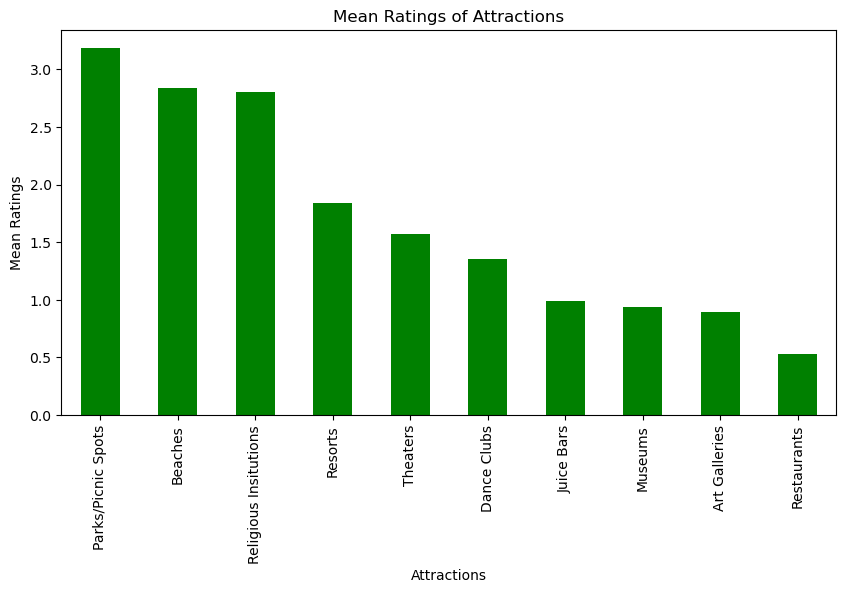

In [12]:
#sorting means from highest to lowest
mean_of_numerics_sorted = mean_of_numerics.sort_values(ascending=False)
print(mean_of_numerics_sorted)

#bar chart of means
plt.figure(figsize=(10,5))
mean_of_numerics_sorted.plot(kind='bar', color='green')
plt.title('Mean Ratings of Attractions')
plt.xlabel('Attractions')
plt.ylabel('Mean Ratings')
plt.show


In [13]:
#dropping the lowest 5 attractions
mean_of_numerics_top5 = mean_of_numerics_sorted.iloc[:-5]
print(mean_of_numerics_top5)

#dropping the 5 columns in the dataframe
trip_top5=trip_data_without_userid[mean_of_numerics_top5.index]
print(trip_top5)

Parks/Picnic Spots       3.180744
Beaches                  2.836854
Religious Insitutions    2.804017
Resorts                  1.841031
Theaters                 1.570925
dtype: float64
     Parks/Picnic Spots  Beaches  Religious Insitutions  Resorts  Theaters
0                  3.19     2.79                   2.42     2.42      1.82
1                  3.21     2.63                   2.32     3.18      1.86
2                  3.18     2.80                   2.50     1.54      1.31
3                  3.18     2.96                   2.86     1.52      1.57
4                  3.18     2.78                   2.54     2.02      1.18
..                  ...      ...                    ...      ...       ...
975                3.17     2.78                   3.20     1.38      0.99
976                3.18     2.79                   2.80     1.68      1.34
977                3.17     2.81                   3.02     1.78      1.34
978                3.18     2.98                   2.46     0.40 

<Axes: >

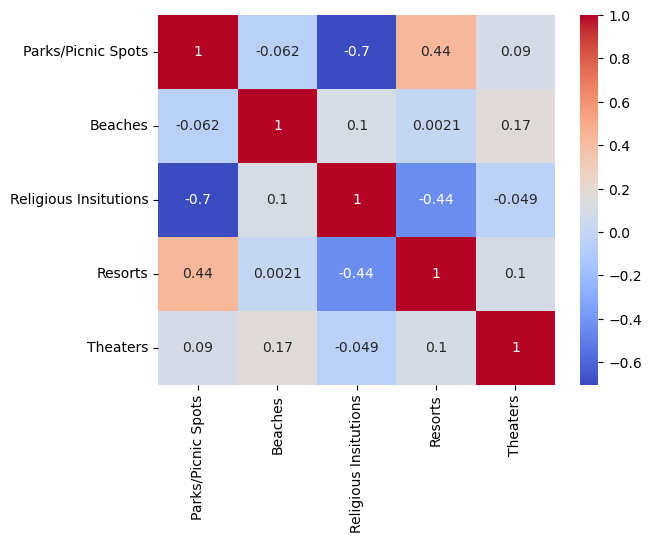

In [45]:
#correlation tests after removing duplicates and reducing features
correlation_matrix_for_initial_data = trip_top5.corr()
correlation_matrix_for_initial_data
sbrn.heatmap(correlation_matrix_for_initial_data, annot=True, cmap='coolwarm')

# K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


ModuleNotFoundError: No module named 'pingoiun'

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
Silhouette Score: 0.2967726639177173


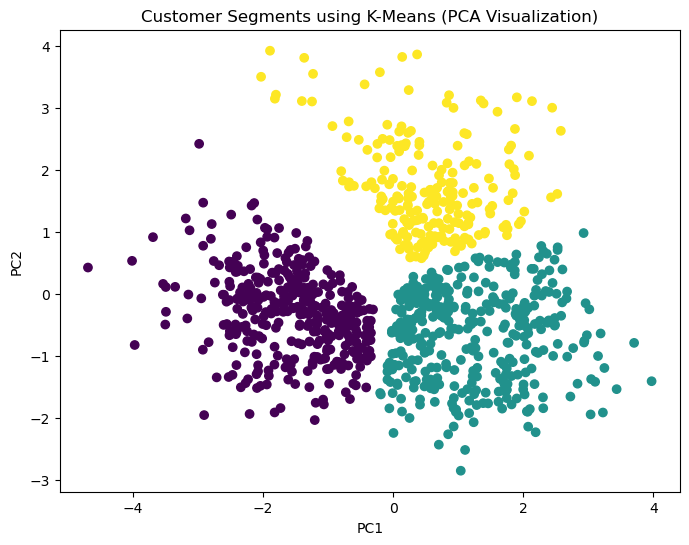

In [ ]:
#Standardizing Data
scaler=StandardScaler()
trip_top5_scaled=scaler.fit_transform(trip_top5)

#convert array back to dataframe
trip_scaled=pd.DataFrame(trip_top5_scaled, columns=trip_top5.columns)
trip_scaled_before = trip_scaled.copy()
trip_top5=pd.DataFrame(trip_top5, columns=trip_top5.columns)

#verifying transformation
print(type(trip_scaled))
print(type(trip_top5))

#Creating Clusters and Silhouette Score
kmeans=KMeans(n_clusters=3, random_state=42)
trip_scaled['cluster']=kmeans.fit_predict(trip_scaled)

print('Silhouette Score:', silhouette_score(trip_scaled, kmeans.fit_predict(trip_scaled)))

#using PCA to visualize clusters
pca=PCA(n_components=2)
components= pca.fit_transform(trip_scaled)

trip_scaled['PC1'] = components[:, 0]
trip_scaled['PC2'] = components[:, 1]

plt.figure(figsize=(8,6))
plt.scatter(trip_scaled['PC1'], trip_scaled['PC2'], 
            c=trip_scaled['cluster'], cmap='viridis')
plt.title('Customer Segments using K-Means (PCA Visualization)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [ ]:
#Bartlett's 
f_value, p_value = stats.f_oneway(trip_scaled_before['Parks/Picnic Spots'], trip_scaled_before['Religious Insitutions'], 
                                  trip_scaled_before_binary_targets['Theaters'], equal_var=False)
print("F-statistic:", f_value)
print("P-statistic:", p_value)
print(stats.bartlett(trip_scaled_before['Parks/Picnic Spots'], trip_scaled_before['Religious Insitutions'], trip_scaled_before_binary_targets['Theaters']))

#Welch's ANOVA
grouping = "cluster"
for column in package:
    print(f"--- Welch's ANOVA for {column} ---")
    aov = pg.welch_anova(dv=column, between=grouping, data=trip_scaled)
    print(aov)
    print("\n")

,Parks/Picnic Spots,Beaches,Religious Insitutions,Resorts,Theaters,cluster,PC1,PC2
0,1.203307,-0.340643,-1.203403,1.069297,0.679072,0,-2.201085,0.398342
1,3.803335,-1.503884,-1.516776,2.472939,0.788127,0,-4.695174,0.423430
2,-0.096707,-0.267941,-0.952706,-0.555973,-0.711377,0,-0.547705,-0.987157
3,-0.096707,0.895300,0.175435,-0.592911,-0.002521,2,0.949153,0.829504
4,-0.096707,-0.413346,-0.827357,0.330538,-1.065805,0,-0.906674,-1.145587
...,...,...,...,...,...,...,...,...
936,-1.396721,-0.413346,1.240902,-0.851477,-1.583816,1,1.898650,-1.686298
937,-0.096707,-0.340643,-0.012588,-0.297407,-0.629586,1,0.185303,-0.630988
938,-1.396721,-0.195238,0.676831,-0.112718,-0.629586,1,1.259692,-0.741552
939,-0.096707,1.040705,-1.078054,-2.661436,-1.229388,1,0.890195,-0.561416


In [ ]:
#computing the mean of each cluster
cluster_mean= trip_top5.groupby('cluster')[trip_scaled_before.columns].mean()
cluster_mean

#top attractions 
top_attraction=cluster_mean.idxmax(axis=1)
top_attraction

#created the 3-attraction package
package=top_attraction.tolist()
print(package)


['Parks/Picnic Spots', 'Religious Insitutions', 'Theaters']


In [94]:
#creating package rating and adding it to the dataframe
trip_data_without_userid['package_rating']= trip_top5[package].mean(axis=1)
trip_data_without_userid

#creating binary target variable, high package rating
t=trip_data_without_userid['package_rating'].mean()
trip_data_without_userid['high_package_rating']=(trip_top5['package_rating']>=t).astype(int)

trip_data_without_userid['high_package_rating'].value_counts()


high_package_rating
0    496
1    445
Name: count, dtype: int64

In [20]:
Predictive Modeling(KNN and Logistic Regression)

SyntaxError: invalid syntax (2795748356.py, line 1)

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [106]:
#splitting dataset into target/features
cols=['Parks/Picnic Spots','Religious Insitutions', 'Theaters', 'high_package_rating', 'package_rating']
X=trip_data_without_userid.drop(columns=cols)
y=trip_data_without_userid['high_package_rating']

#Verifying change
X.head()
y.value_counts()

#splitting dataset into 80/20 with stratification
X_train, X_test, y_train, y_test= train_test_split(
    X,y, train_size=.80, random_state=42, stratify=y
)

#Scaling reduced data
scaler=StandardScaler()
#fitting on training data only, tranforming test data 
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [107]:
#Hyperparamter Tuning for Logistic Regression
log_reg=LogisticRegression(max_iter=10000)

param_grid_lr= {
    'C': [0.01, 0.1, 1, 10],
    'penalty':['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_lr=GridSearchCV(estimator=log_reg, param_grid=param_grid_lr, cv=5)

#fitting best params to dataset
grid_lr.fit(X_train_scaled, y_train)

best_lr=grid_lr.best_estimator_

#Print the Hyperparameters and CV Score
print('GridSearchCV Best Params:', grid_lr.best_params_)
print('GridSearchCV Best Cross-Validation Score:', grid_lr.best_score_)


GridSearchCV Best Params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
GridSearchCV Best Cross-Validation Score: 0.6914613686534217


In [108]:
y_pred_lr=best_lr.predict(X_test_scaled)

print('LogReg Accuracy:', accuracy_score(y_test, y_pred_lr))
print('LogReg F1 Score:', f1_score(y_test, y_pred_lr))
print('LogReg Precision Score:', precision_score(y_test, y_pred_lr))
print('LogReg Recall Score:', recall_score(y_test,y_pred_lr))

LogReg Accuracy: 0.7195767195767195
LogReg F1 Score: 0.7135135135135136
LogReg Precision Score: 0.6875
LogReg Recall Score: 0.7415730337078652


In [109]:
#Hyperparameter Tuning for KNN
knn=KNeighborsClassifier()

param_grid_knn= {
    'n_neighbors':[3,5,7,9,11,15,21],
    'weights':['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_KNN= GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5)

#fitting to dataset
grid_KNN.fit(X_train_scaled, y_train)

best_knn=grid_KNN.best_estimator_

print('GridSearchCV Best Params:', grid_KNN.best_params_)
print('GridSearchCV Best Cross-Validation Score:', grid_KNN.best_score_)

GridSearchCV Best Params: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
GridSearchCV Best Cross-Validation Score: 0.6954613686534217


In [110]:
#Testing KNN Model
y_pred_knn= best_knn.predict(X_test_scaled)

print('KNN Accuracy:', accuracy_score(y_test, y_pred_knn))
print('KNN F1 Score:', f1_score(y_test, y_pred_knn))
print('KNN Precision Score:', precision_score(y_test, y_pred_knn))
print('KNN Recall Score:', recall_score(y_test,y_pred_knn))

KNN Accuracy: 0.6931216931216931
KNN F1 Score: 0.7010309278350515
KNN Precision Score: 0.6476190476190476
KNN Recall Score: 0.7640449438202247
